# Gaussian Diagnostics

Original QMCPy demo: [`QMCPy/demos/gaussian_diagnostics/gaussian_diagnostics_demo.ipynb`](../../../QMCPy/demos/gaussian_diagnostics/gaussian_diagnostics_demo.ipynb)

The QMCPy notebook studies diagnostics related to the Gaussian-process assumptions behind Bayesian cubature across several worked examples. This Julia translation keeps the same Gaussian-diagnostics theme by focusing on the corresponding `QMC.jl` ingredients: a Bayesian lattice solve, shift-invariant kernel eigenvalues, and a positive-semidefinite stationary kernel matrix.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/gaussian_diagnostics/gaussian_diagnostics_demo.ipynb)

Parity note: this Julia notebook preserves the same Gaussian-diagnostics motivation from QMCPy, but it compresses the broader Python engine-and-figure sweep into a smaller Julia set of representative checks: one Bayesian lattice solve, one shift-invariant kernel eigenvalue-decay diagnostic, and one positive-semidefinite stationary kernel-matrix test.


In [1]:
using QMC
using LinearAlgebra
using Statistics
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## Example 1: Exponential of Cosine

The QMCPy notebook opens with several Gaussian-diagnostics examples tied to Bayesian lattice cubature. Here we define a compact Bayesian cubature problem and inspect the recorded diagnostics as the Julia analogue of that first example.


In [2]:
dd = Lattice(3; seed=7)
f = Genz(Uniform(dd); kind=:continuous, a=ones(3), u=0.5 .* ones(3))
result = integrate(CubQMCBayesLatticeG(f; abs_tol=1e-3, trace_iterations=true))
@printf("Bayesian lattice estimate = %.8f, n_total = %d, error_bound = %.3e
", result.solution, result.data[:n_total], result.data[:error_bound])
iterations(result.data[:iteration_log])


Bayesian lattice estimate = 0.48536791, n_total = 256, error_bound = 4.679e-05


iter,n,solution,err_bound,tol,time(s)
1,256,0.48536791,4.679e-05,1.000e-03,0.019


## Example 2: Random function

For lattice points, `QMC.jl` exposes the eigenvalues of the shift-invariant kernel directly. Their decay summarizes how concentrated the kernel energy is and plays the same diagnostic role as the random-function examples in QMCPy.


In [3]:
x_lattice = gen_samples(dd, 64)
λ = compute_kernel_eigenvalues(KernelShiftInvar(order=2), x_lattice)
effective_rank = (sum(λ)^2) / sum(λ .^ 2)
@printf("First six eigenvalues: %s
", string(round.(λ[1:6], digits=6)))
@printf("Effective rank = %.3f
", effective_rank)

@assert all(isfinite, λ)


First six eigenvalues: [64.000028, 0.008139, 0.006927, 0.011478, 0.057491, 0.027142]
Effective rank = 1.216


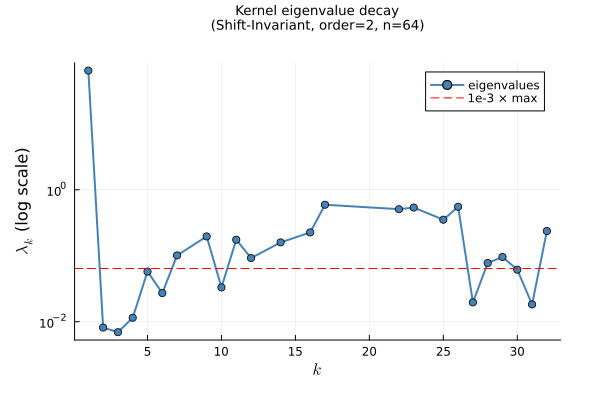

In [4]:
if HAVE_PLOTS
    k_show  = min(32, length(λ))
    idx_pos = findall(>(0), λ[1:k_show])
    λ_pos   = λ[idx_pos]
    p = plot(idx_pos, λ_pos;
        marker=:circle, lw=2, ms=4, color=:steelblue,
        yscale=:log10,
        xlabel="\$k\$",
        ylabel="\$\\lambda_k\$ (log scale)",
        title="Kernel eigenvalue decay\n(Shift-Invariant, order=2, n=64)",
        label="eigenvalues")
    hline!([maximum(λ_pos) * 1e-3]; lw=1, color=:red, linestyle=:dash, label="1e-3 × max")
    display(p)
end


### Plot additional figures for random function

A Gaussian-process covariance kernel must generate a positive-semidefinite Gram matrix. We check that property for a Matérn kernel on a one-dimensional grid.


In [5]:
x_grid = reshape(range(0.0, 1.0; length=16), :, 1)
K = kernel_matrix(KernelMatern32(lengthscale=0.3, outputscale=1.5), x_grid)
eigs = eigvals(Symmetric(K))
@printf("trace(K) = %.6f, smallest eigenvalue = %.8f, largest eigenvalue = %.8f
", tr(K), minimum(eigs), maximum(eigs))

@assert minimum(eigs) > -1e-10
@assert result.data[:converged]


trace(K) = 24.000000, smallest eigenvalue = 0.00719973, largest eigenvalue = 12.17819039


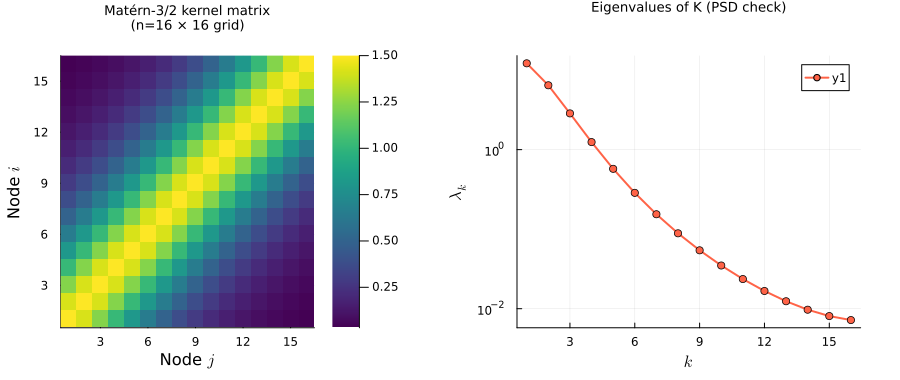

In [6]:
if HAVE_PLOTS
    p1 = heatmap(K;
        color=:viridis,
        xlabel="Node \$j\$", ylabel="Node \$i\$",
        title="Matérn-3/2 kernel matrix\n(n=16 × 16 grid)",
        colorbar=true)
    p2 = plot(1:length(eigs), sort(eigs, rev=true);
        marker=:circle, lw=2, ms=4, color=:tomato,
        yscale=:log10,
        xlabel="\$k\$", ylabel="\$\\lambda_k\$",
        title="Eigenvalues of K (PSD check)")
    display(plot(p1, p2; layout=(1, 2), size=(900, 380)))
end


## Example 3a: Keister integrand: npts = 64

The QMCPy notebook includes Keister-specific Gaussian-diagnostics plots at fixed sample sizes. The checked-in Julia notebook does not keep those figure-specific cases as separate executed cells, but this heading records the corresponding parity target explicitly.


## Example 3b: Keister integrand: npts = 1024

The higher-resolution Keister diagnostic from QMCPy is likewise not broken out as its own checked-in Julia run. It remains a documented parity target rather than an untracked omission.
